# E-Commerce Customer Behavior Case Study

**Goal:** Analyze user behavior for an e-commerce company, identify the largest funnel drop-off, and recommend actions that can improve sales performance.

**Dataset:** `events.csv`

**Deliverables in this notebook**
- Business problem framing and data questions
- KPI definitions
- Data quality and cleaning summary
- Exploratory data analysis
- Funnel analysis
- User behavior segmentation
- Dashboard-style visuals
- Final business recommendations

## 1. Business Understanding

### Business problem
An e-commerce business wants to understand how customers move from product discovery to purchase, where users drop off in the funnel, and which products, brands, and categories drive the strongest commercial outcomes.

### Key data questions
1. How many users view products, add to cart, and purchase?
2. Which products, brands, and categories perform best?
3. Which month has the highest revenue?
4. Which hour has the highest activity?
5. Where is the largest funnel drop-off?
6. Which users abandon after cart?
7. What recommendations should management act on next?

### Analytical assumptions
- One row represents one user event.
- `user_id` identifies a unique customer.
- `user_session` identifies a browsing session.
- The target business action is a **purchase**.
- Revenue is calculated from `price` on `purchase` events only.
- Funnel stages are determined by `event_type`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.dpi"] = 120

pd.options.display.float_format = "{:,.2f}".format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "events.csv").exists() and (PROJECT_ROOT.parent / "events.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "events.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

def fmt_currency(value):
    return f"${value:,.2f}"

def fmt_percent(value):
    return f"{value:.2%}"

## 2. Understand the Dataset

The first job is to inspect the schema before doing any KPI work or charting. This helps us separate event-level fields from user-level fields and understand what can support revenue, funnel, and behavioral analysis.

In [2]:
dtype_map = {
    "event_type": "category",
    "product_id": "string",
    "category_id": "string",
    "category_code": "string",
    "brand": "string",
    "price": "float64",
    "user_id": "string",
    "user_session": "string",
}

raw = pd.read_csv(DATA_PATH, dtype=dtype_map, low_memory=False)
raw["event_time"] = pd.to_datetime(raw["event_time"], utc=True, errors="coerce")

print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head())

schema = pd.DataFrame(
    {
        "column": raw.columns,
        "dtype": raw.dtypes.astype(str).values,
        "missing_values": raw.isna().sum().values,
        "missing_pct": (raw.isna().mean() * 100).round(2).values,
        "unique_values": [raw[col].nunique(dropna=True) for col in raw.columns],
    }
)
display(schema)

Raw shape: 885,129 rows x 9 columns


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,<NA>,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,<NA>,<NA>,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,<NA>,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


,column,dtype,missing_values,missing_pct,unique_values
0,event_time,"datetime64[us, UTC]",0,0.00,845041
1,event_type,category,0,0.00,3
2,product_id,string,0,0.00,53453
3,category_id,string,0,0.00,718
4,category_code,string,236219,26.69,107
5,brand,string,212364,23.99,999
6,price,float64,0,0.00,12422
7,user_id,string,0,0.00,407283
8,user_session,string,165,0.02,490398


In [3]:
business_definition = pd.DataFrame(
    [
        {"question": "What is one row?", "answer": "One event generated by one user during one session."},
        {"question": "What is one user?", "answer": "`user_id` represents a unique customer identifier."},
        {"question": "What is one session?", "answer": "`user_session` groups related browsing actions in a visit."},
        {"question": "What is the target business action?", "answer": "A completed purchase."},
        {"question": "Which column calculates revenue?", "answer": "`price`, filtered to `purchase` events only."},
        {"question": "Which column builds the funnel?", "answer": "`event_type` with stages `view`, `cart`, and `purchase`."},
    ]
)
display(business_definition)

,question,answer
0,What is one row?,One event generated by one user during one ses...
1,What is one user?,`user_id` represents a unique customer identif...
2,What is one session?,`user_session` groups related browsing actions...
3,What is the target business action?,A completed purchase.
4,Which column calculates revenue?,"`price`, filtered to `purchase` events only."
5,Which column builds the funnel?,"`event_type` with stages `view`, `cart`, and `..."


## 3. KPI Definitions

KPIs translate the business goal into measurable metrics. Every downstream chart in this notebook is tied back to one or more KPIs below.

In [4]:
kpi_definitions = pd.DataFrame(
    [
        {"KPI": "Total users", "Definition": "Unique users in the dataset", "Formula": "nunique(user_id)"},
        {"KPI": "Total sessions", "Definition": "Unique browsing sessions", "Formula": "nunique(user_session)"},
        {"KPI": "Total product views", "Definition": "Count of `view` events", "Formula": "count(event_type == 'view')"},
        {"KPI": "Total cart events", "Definition": "Count of `cart` events", "Formula": "count(event_type == 'cart')"},
        {"KPI": "Total purchases", "Definition": "Count of `purchase` events", "Formula": "count(event_type == 'purchase')"},
        {"KPI": "Total revenue", "Definition": "Revenue generated from purchase events", "Formula": "sum(price where event_type == 'purchase')"},
        {"KPI": "Average order value", "Definition": "Average revenue per purchase event", "Formula": "total revenue / total purchases"},
        {"KPI": "Conversion rate", "Definition": "Share of all users who purchased", "Formula": "purchasing users / total users"},
        {"KPI": "Cart-to-purchase rate", "Definition": "How efficiently carts become orders", "Formula": "purchase events / cart events"},
        {"KPI": "Monthly revenue trend", "Definition": "Revenue movement over time", "Formula": "sum(purchase price) by month"},
    ]
)
display(kpi_definitions)

,KPI,Definition,Formula
0,Total users,Unique users in the dataset,nunique(user_id)
1,Total sessions,Unique browsing sessions,nunique(user_session)
2,Total product views,Count of `view` events,count(event_type == 'view')
3,Total cart events,Count of `cart` events,count(event_type == 'cart')
4,Total purchases,Count of `purchase` events,count(event_type == 'purchase')
5,Total revenue,Revenue generated from purchase events,sum(price where event_type == 'purchase')
6,Average order value,Average revenue per purchase event,total revenue / total purchases
7,Conversion rate,Share of all users who purchased,purchasing users / total users
8,Cart-to-purchase rate,How efficiently carts become orders,purchase events / cart events
9,Monthly revenue trend,Revenue movement over time,sum(purchase price) by month


## 4. Data Cleaning

Good analysis starts with explicit cleaning choices. The workflow below documents the checks and the exact transformation logic used to make the dataset analysis-ready.

In [5]:
duplicate_rows = int(raw.duplicated().sum())
invalid_event_time = int(raw["event_time"].isna().sum())
non_positive_price = int((raw["price"] <= 0).sum())
missing_brand = int(raw["brand"].isna().sum())
missing_category = int(raw["category_code"].isna().sum())
missing_session = int(raw["user_session"].isna().sum())

clean = raw.drop_duplicates().copy()
clean = clean.loc[clean["event_time"].notna()].copy()
clean = clean.loc[clean["price"] > 0].copy()

clean["brand"] = clean["brand"].fillna("Unknown")
clean["category_code"] = clean["category_code"].fillna("Unknown")
clean["event_time"] = clean["event_time"].dt.tz_localize(None)
clean["event_date"] = clean["event_time"].dt.normalize()
clean["event_month"] = clean["event_time"].dt.to_period("M").astype(str)
clean["event_day"] = pd.Categorical(
    clean["event_time"].dt.day_name(),
    categories=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
    ordered=True,
)
clean["event_hour"] = clean["event_time"].dt.hour
clean["event_type"] = pd.Categorical(
    clean["event_type"],
    categories=["view", "cart", "purchase"],
    ordered=True,
)

quality_summary = pd.DataFrame(
    [
        {"check": "Raw rows", "value": raw.shape[0], "decision": "Starting point"},
        {"check": "Duplicate rows", "value": duplicate_rows, "decision": "Removed duplicates"},
        {"check": "Invalid event_time", "value": invalid_event_time, "decision": "No invalid timestamps found"},
        {"check": "Non-positive prices", "value": non_positive_price, "decision": "No zero or negative prices found"},
        {"check": "Missing brands", "value": missing_brand, "decision": "Filled with 'Unknown'"},
        {"check": "Missing category_code", "value": missing_category, "decision": "Filled with 'Unknown'"},
        {"check": "Missing user_session", "value": missing_session, "decision": "Retained as missing; excluded naturally from `nunique` session counts"},
        {"check": "Clean rows", "value": clean.shape[0], "decision": "Analysis-ready dataset"},
    ]
)
display(quality_summary)

,check,value,decision
0,Raw rows,885129,Starting point
1,Duplicate rows,655,Removed duplicates
2,Invalid event_time,0,No invalid timestamps found
3,Non-positive prices,0,No zero or negative prices found
4,Missing brands,212364,Filled with 'Unknown'
5,Missing category_code,236219,Filled with 'Unknown'
6,Missing user_session,165,Retained as missing; excluded naturally from `...
7,Clean rows,884474,Analysis-ready dataset


In [6]:
cleaning_notes = [
    "Replaced missing `brand` with 'Unknown' to keep brand-level aggregations consistent.",
    "Replaced missing `category_code` with 'Unknown' to preserve row counts in category analysis.",
    "Removed exact duplicate rows to avoid inflating KPIs and funnel stages.",
    "Kept missing `user_session` as null rather than creating synthetic sessions.",
    "Derived `event_date`, `event_month`, `event_day`, and `event_hour` for trend and behavior analysis.",
]

for note in cleaning_notes:
    print(f"- {note}")

- Replaced missing `brand` with 'Unknown' to keep brand-level aggregations consistent.
- Replaced missing `category_code` with 'Unknown' to preserve row counts in category analysis.
- Removed exact duplicate rows to avoid inflating KPIs and funnel stages.
- Kept missing `user_session` as null rather than creating synthetic sessions.
- Derived `event_date`, `event_month`, `event_day`, and `event_hour` for trend and behavior analysis.


## 5. KPI Calculation

With the cleaned dataset ready, we can calculate the headline commercial and behavioral KPIs.

In [7]:
purchase_df = clean.loc[clean["event_type"] == "purchase"].copy()
cart_df = clean.loc[clean["event_type"] == "cart"].copy()
view_df = clean.loc[clean["event_type"] == "view"].copy()

total_users = clean["user_id"].nunique()
total_sessions = clean["user_session"].nunique(dropna=True)
purchasing_users = purchase_df["user_id"].nunique()
cart_users = cart_df["user_id"].nunique()
view_users = view_df["user_id"].nunique()

total_revenue = purchase_df["price"].sum()
total_purchases = len(purchase_df)
total_carts = len(cart_df)
total_views = len(view_df)

average_order_value = total_revenue / total_purchases
conversion_rate = purchasing_users / total_users
view_to_cart_user_rate = cart_users / view_users
cart_to_purchase_user_rate = purchasing_users / cart_users
cart_to_purchase_event_rate = total_purchases / total_carts
overall_funnel_rate = purchasing_users / view_users

kpi_summary = pd.DataFrame(
    [
        {"KPI": "Total users", "Value": f"{total_users:,}"},
        {"KPI": "Total sessions", "Value": f"{total_sessions:,}"},
        {"KPI": "Total product views", "Value": f"{total_views:,}"},
        {"KPI": "Total cart events", "Value": f"{total_carts:,}"},
        {"KPI": "Total purchases", "Value": f"{total_purchases:,}"},
        {"KPI": "Total revenue", "Value": fmt_currency(total_revenue)},
        {"KPI": "Average order value", "Value": fmt_currency(average_order_value)},
        {"KPI": "Conversion rate", "Value": fmt_percent(conversion_rate)},
        {"KPI": "View-to-cart user rate", "Value": fmt_percent(view_to_cart_user_rate)},
        {"KPI": "Cart-to-purchase user rate", "Value": fmt_percent(cart_to_purchase_user_rate)},
        {"KPI": "Cart-to-purchase event rate", "Value": fmt_percent(cart_to_purchase_event_rate)},
        {"KPI": "Overall funnel conversion", "Value": fmt_percent(overall_funnel_rate)},
    ]
)
display(kpi_summary)

,KPI,Value
0,Total users,"407,283"
1,Total sessions,"490,398"
2,Total product views,"793,099"
3,Total cart events,"54,032"
4,Total purchases,"37,343"
5,Total revenue,"$5,125,113.92"
6,Average order value,$137.24
7,Conversion rate,5.23%
8,View-to-cart user rate,9.08%
9,Cart-to-purchase user rate,57.65%


## 6. Exploratory Data Analysis

We start with the simplest descriptive questions: event mix, trend over time, top-performing commercial drivers, and product-level conversion patterns.

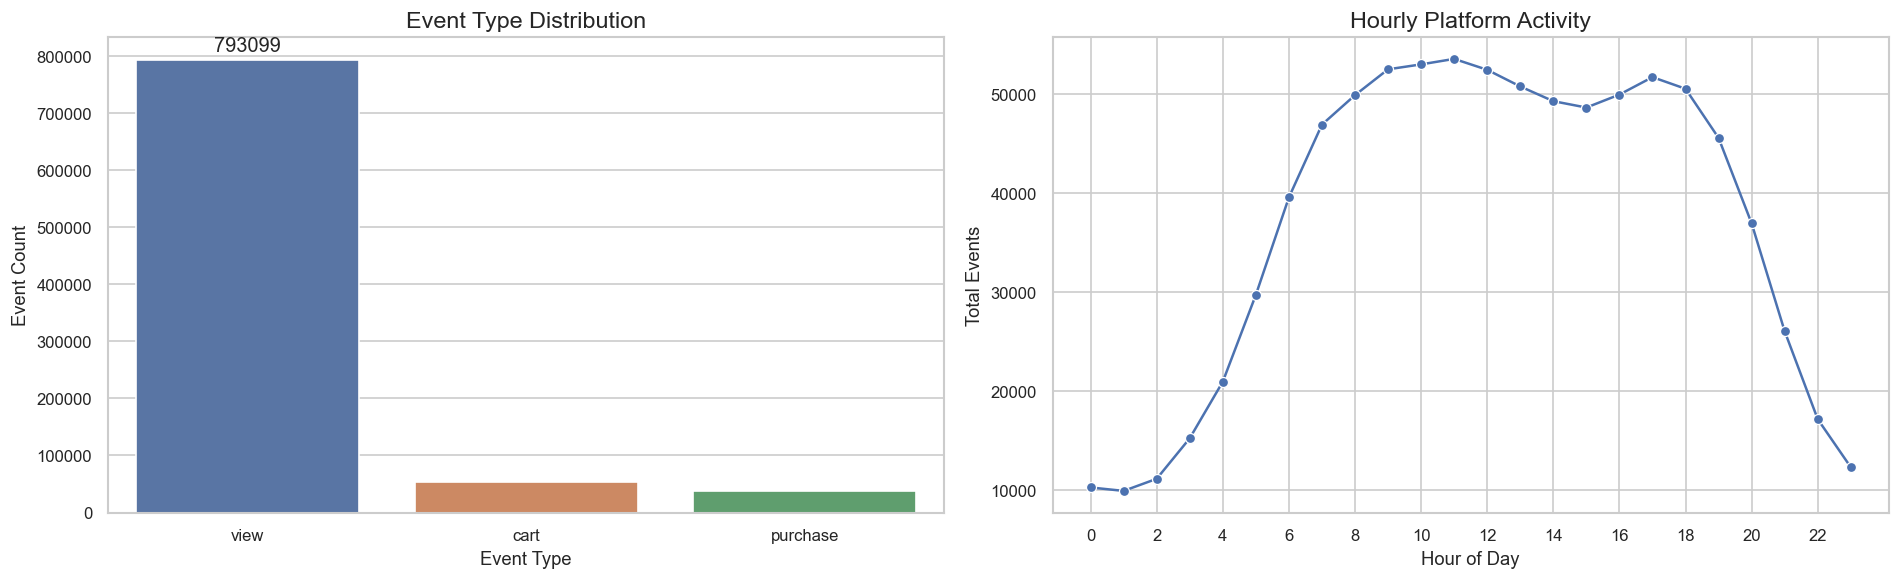

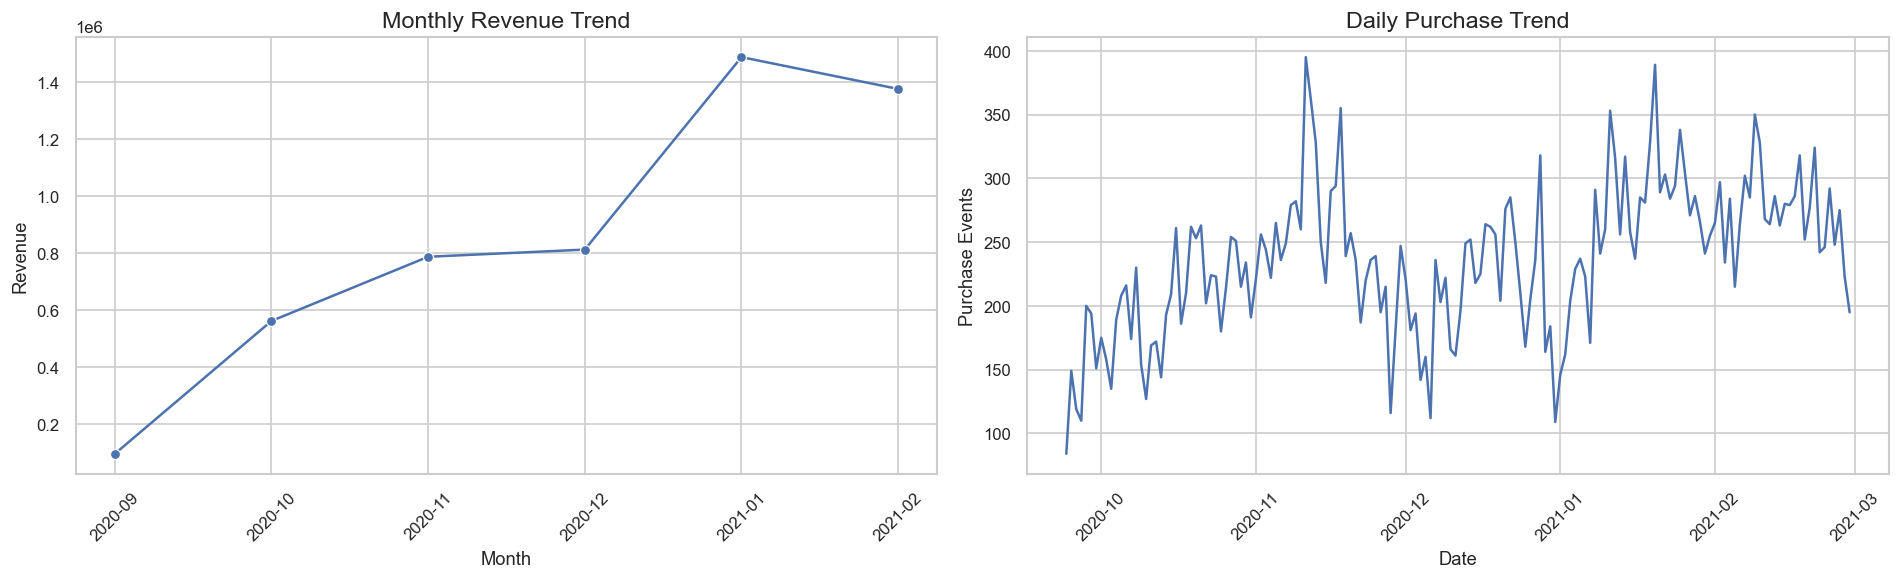

In [8]:
event_counts = clean["event_type"].value_counts().reindex(["view", "cart", "purchase"])
hourly_activity = clean.groupby("event_hour").size()
daily_purchases = purchase_df.groupby("event_date").size()
monthly_revenue = purchase_df.groupby("event_month")["price"].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    x=event_counts.index,
    y=event_counts.values,
    hue=event_counts.index,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Event Type Distribution")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Event Count")
axes[0].bar_label(axes[0].containers[0], fmt="%.0f", padding=3)

sns.lineplot(
    x=hourly_activity.index,
    y=hourly_activity.values,
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Hourly Platform Activity")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Total Events")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o", ax=axes[0])
axes[0].set_title("Monthly Revenue Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(x=daily_purchases.index, y=daily_purchases.values, ax=axes[1])
axes[1].set_title("Daily Purchase Trend")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Purchase Events")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

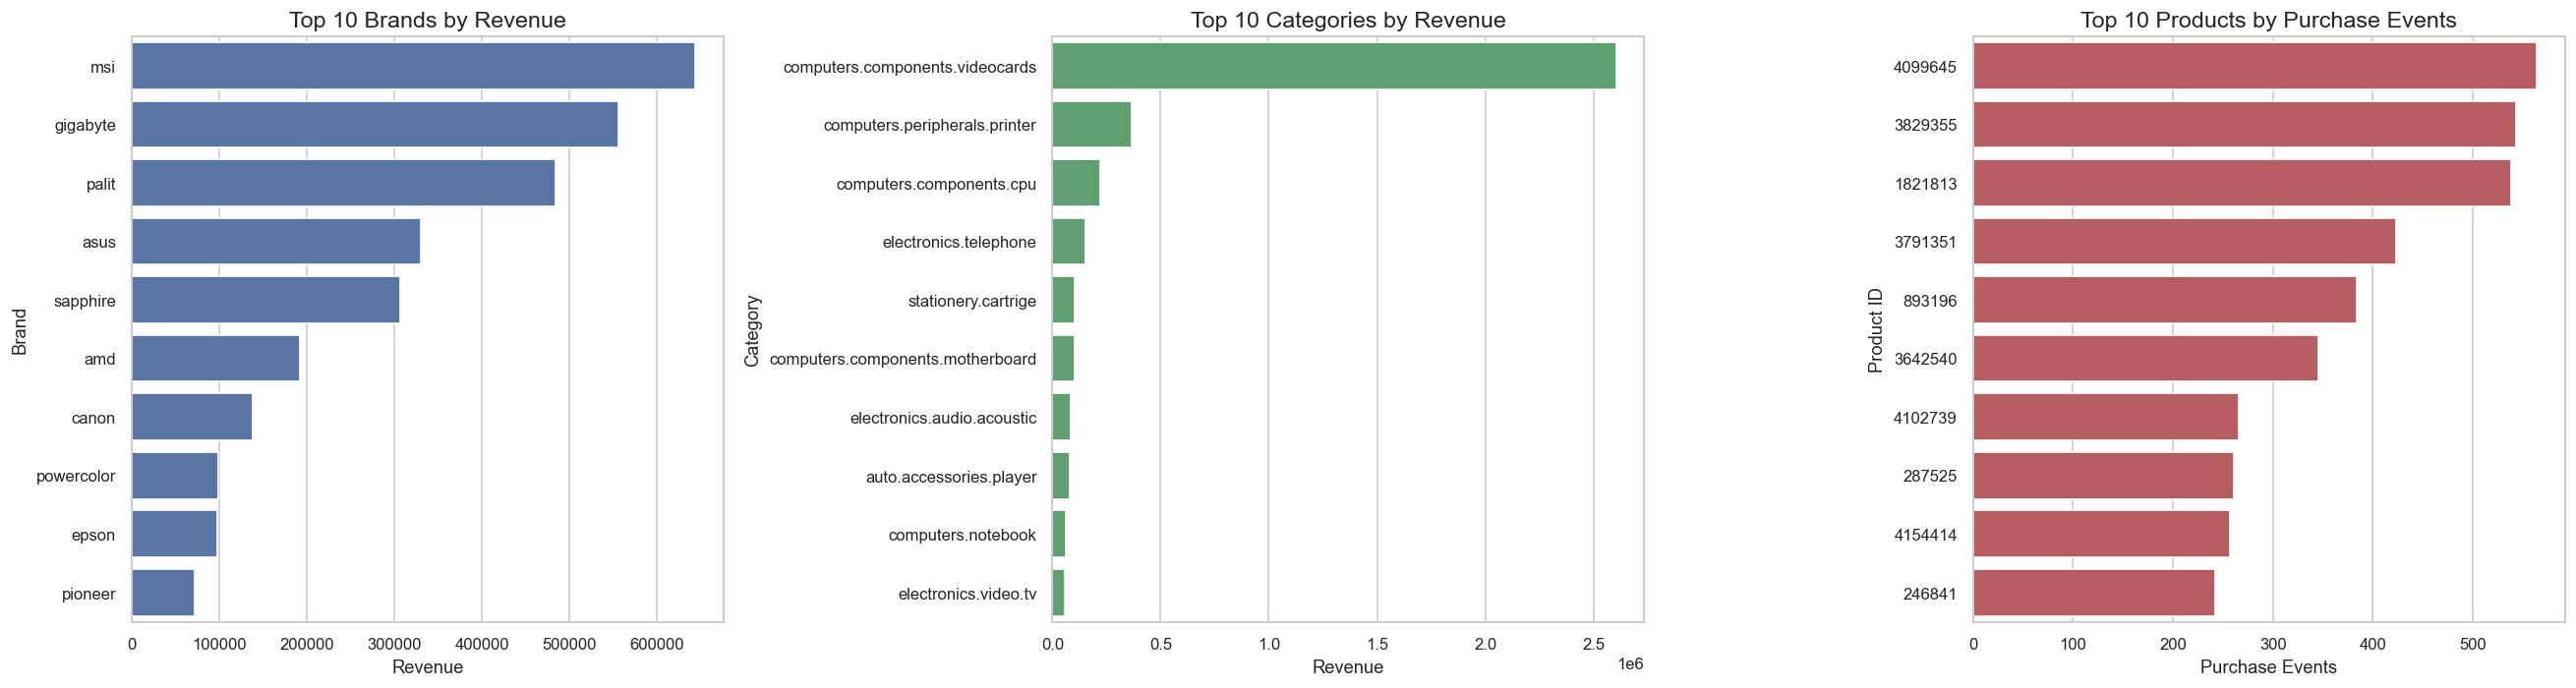

,revenue,purchases
brand,,
msi,"643,492.34",1788
Unknown,"594,720.15",9500
gigabyte,"556,183.04",1741
palit,"484,210.58",1077
asus,"330,147.11",1261
sapphire,"306,192.94",917
amd,"191,987.40",1020
canon,"137,964.79",1045
powercolor,"98,804.38",272


,revenue,purchases
category_code,,
computers.components.videocards,"2,604,764.80",6888
Unknown,"493,896.91",7566
computers.peripherals.printer,"364,566.80",2557
computers.components.cpu,"219,168.98",1213
electronics.telephone,"150,915.69",4119
stationery.cartrige,"103,595.99",2739
computers.components.motherboard,"102,871.16",1266
electronics.audio.acoustic,"84,724.80",848
auto.accessories.player,"81,558.66",685


,purchases,revenue
product_id,,
4099645,564,"165,156.12"
3829355,543,"17,495.46"
1821813,538,"213,844.24"
3791351,423,"86,414.67"
893196,384,"82,214.40"
3642540,345,"9,035.55"
4102739,266,"78,313.06"
287525,261,"2,440.35"
4154414,257,"52,086.19"


In [9]:
brand_revenue = (
    purchase_df.groupby("brand")
    .agg(revenue=("price", "sum"), purchases=("event_type", "size"))
    .sort_values("revenue", ascending=False)
)
category_revenue = (
    purchase_df.groupby("category_code")
    .agg(revenue=("price", "sum"), purchases=("event_type", "size"))
    .sort_values("revenue", ascending=False)
)
product_purchases = (
    purchase_df.groupby("product_id")
    .agg(purchases=("event_type", "size"), revenue=("price", "sum"))
    .sort_values(["purchases", "revenue"], ascending=[False, False])
)

top_brand_chart = brand_revenue.loc[brand_revenue.index != "Unknown"].head(10).reset_index()
top_category_chart = category_revenue.loc[category_revenue.index != "Unknown"].head(10).reset_index()
top_product_chart = product_purchases.head(10).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=top_brand_chart, x="revenue", y="brand", ax=axes[0], color="#4c72b0")
axes[0].set_title("Top 10 Brands by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Brand")

sns.barplot(data=top_category_chart, x="revenue", y="category_code", ax=axes[1], color="#55a868")
axes[1].set_title("Top 10 Categories by Revenue")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Category")

sns.barplot(data=top_product_chart, x="purchases", y="product_id", ax=axes[2], color="#c44e52")
axes[2].set_title("Top 10 Products by Purchase Events")
axes[2].set_xlabel("Purchase Events")
axes[2].set_ylabel("Product ID")

plt.tight_layout()
plt.show()

display(brand_revenue.head(10))
display(category_revenue.head(10))
display(product_purchases.head(10))

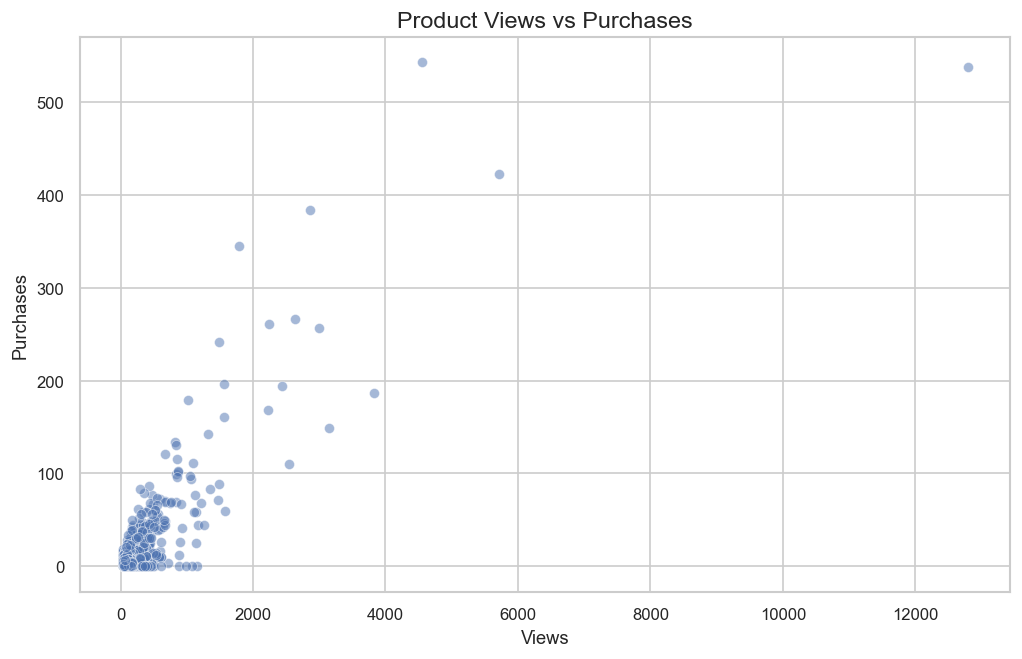

,product_id,views,purchases,purchase_rate,view_purchase_gap
0,229036,"1,150.00",0.00,0.00,"1,150.00"
1,775032,"1,086.00",0.00,0.00,"1,086.00"
2,83737,995.00,0.00,0.00,995.00
3,1674260,946.00,0.00,0.00,946.00
4,589968,891.00,0.00,0.00,891.00
5,1255165,879.00,0.00,0.00,879.00
6,698803,724.00,0.00,0.00,724.00
7,261923,615.00,0.00,0.00,615.00
8,3830671,610.00,0.00,0.00,610.00
9,145379,513.00,0.00,0.00,513.00


In [10]:
product_views = view_df.groupby("product_id").size().rename("views")
product_buys = purchase_df.groupby("product_id").size().rename("purchases")
product_perf = pd.concat([product_views, product_buys], axis=1).fillna(0)
product_perf["purchase_rate"] = np.where(
    product_perf["views"] > 0,
    product_perf["purchases"] / product_perf["views"],
    0,
)
product_perf["view_purchase_gap"] = product_perf["views"] - product_perf["purchases"]

qualified_products = product_perf.loc[product_perf["views"] >= 30].copy()
low_conversion_products = (
    qualified_products.sort_values(["purchase_rate", "views"], ascending=[True, False]).head(10)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=qualified_products.sample(min(3000, len(qualified_products)), random_state=42),
    x="views",
    y="purchases",
    alpha=0.5,
)
plt.title("Product Views vs Purchases")
plt.xlabel("Views")
plt.ylabel("Purchases")
plt.show()

display(low_conversion_products.reset_index())

## 7. Funnel Analysis

This section focuses on the most important business question: where customers drop off between viewing, carting, and purchasing.

,stage,users,conversion_from_previous,drop_off_from_previous
0,Viewed users,406863,100.00%,0.00%
1,Cart users,36952,9.08%,90.92%
2,Purchasing users,21304,57.65%,42.35%


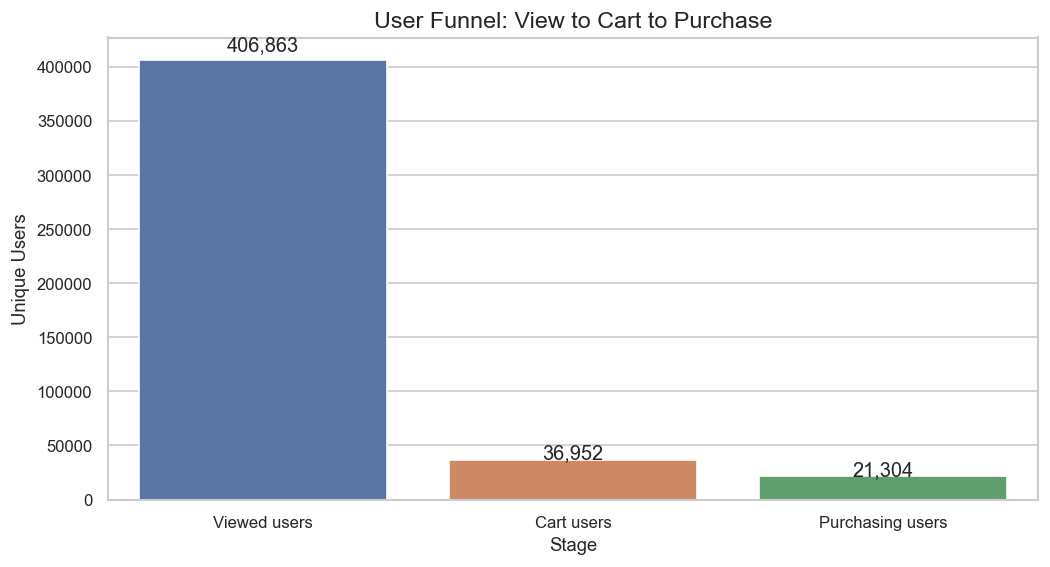

In [11]:
funnel_summary = pd.DataFrame(
    [
        {
            "stage": "Viewed users",
            "users": view_users,
            "conversion_from_previous": 1.0,
            "drop_off_from_previous": 0.0,
        },
        {
            "stage": "Cart users",
            "users": cart_users,
            "conversion_from_previous": cart_users / view_users,
            "drop_off_from_previous": 1 - (cart_users / view_users),
        },
        {
            "stage": "Purchasing users",
            "users": purchasing_users,
            "conversion_from_previous": purchasing_users / cart_users,
            "drop_off_from_previous": 1 - (purchasing_users / cart_users),
        },
    ]
)

funnel_display = funnel_summary.copy()
funnel_display["conversion_from_previous"] = funnel_display["conversion_from_previous"].map(fmt_percent)
funnel_display["drop_off_from_previous"] = funnel_display["drop_off_from_previous"].map(fmt_percent)
display(funnel_display)

plt.figure(figsize=(10, 5))
sns.barplot(data=funnel_summary, x="stage", y="users", hue="stage", legend=False)
plt.title("User Funnel: View to Cart to Purchase")
plt.xlabel("Stage")
plt.ylabel("Unique Users")
for idx, value in enumerate(funnel_summary["users"]):
    plt.text(idx, value + (value * 0.02), f"{value:,}", ha="center")
plt.show()

In [12]:
biggest_drop_stage = "View to Cart" if (1 - view_to_cart_user_rate) > (1 - cart_to_purchase_user_rate) else "Cart to Purchase"

display(
    Markdown(
        f'''
### Funnel Interpretation

- Viewed users: **{view_users:,}**
- Cart users: **{cart_users:,}**
- Purchasing users: **{purchasing_users:,}**
- View-to-cart conversion: **{fmt_percent(view_to_cart_user_rate)}**
- Cart-to-purchase conversion: **{fmt_percent(cart_to_purchase_user_rate)}**
- Overall conversion from viewed users to purchasing users: **{fmt_percent(overall_funnel_rate)}**
- Biggest drop-off: **{biggest_drop_stage}**
'''
    )
)


### Funnel Interpretation

- Viewed users: **406,863**
- Cart users: **36,952**
- Purchasing users: **21,304**
- View-to-cart conversion: **9.08%**
- Cart-to-purchase conversion: **57.65%**
- Overall conversion from viewed users to purchasing users: **5.24%**
- Biggest drop-off: **View to Cart**


## 8. Customer Behavior Analysis

User segmentation helps the business act differently for browsers, abandoners, and loyal purchasers.

,segment,users,share_of_all_users
0,View only users,369083,90.62%
1,Cart abandoners,16896,4.15%
2,Purchased once,13598,3.34%
3,Purchased multiple times,7706,1.89%
4,High-value users (top 10% of purchasers by rev...,2131,0.52%


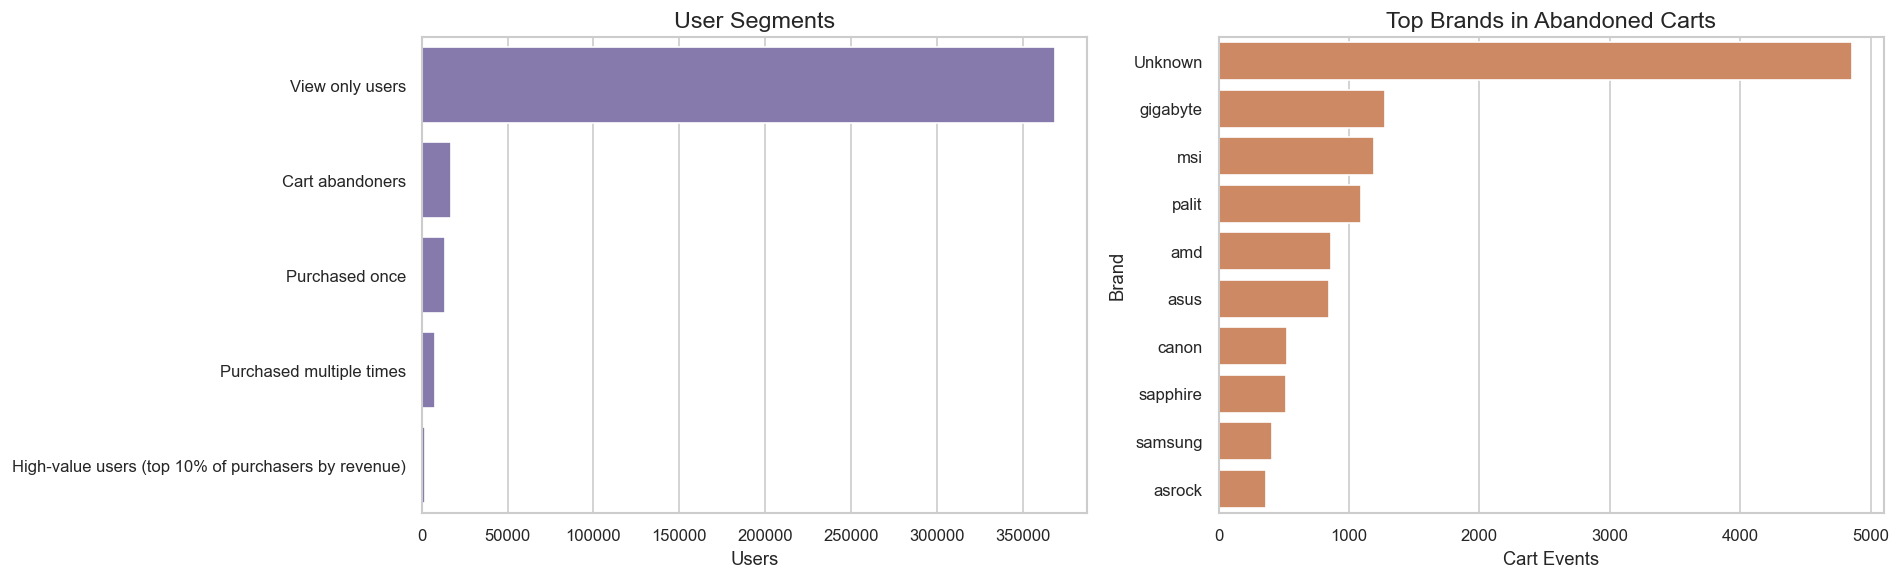

,brand,cart_events
0,Unknown,4860
1,gigabyte,1277
2,msi,1192
3,palit,1091
4,amd,860
5,asus,844
6,canon,521
7,sapphire,517
8,samsung,413
9,asrock,366


In [13]:
user_summary = clean.pivot_table(
    index="user_id",
    columns="event_type",
    values="product_id",
    aggfunc="count",
    fill_value=0,
)

for col in ["view", "cart", "purchase"]:
    if col not in user_summary.columns:
        user_summary[col] = 0

user_summary = user_summary[["view", "cart", "purchase"]]

purchase_events_per_user = purchase_df.groupby("user_id").size().rename("purchase_events")
revenue_per_user = purchase_df.groupby("user_id")["price"].sum().rename("revenue")

user_summary = user_summary.join(purchase_events_per_user, how="left")
user_summary = user_summary.join(revenue_per_user, how="left")
user_summary[["purchase_events", "revenue"]] = user_summary[["purchase_events", "revenue"]].fillna(0)

segment_table = pd.DataFrame(
    [
        {
            "segment": "View only users",
            "users": int(((user_summary["view"] > 0) & (user_summary["cart"] == 0) & (user_summary["purchase"] == 0)).sum()),
        },
        {
            "segment": "Cart abandoners",
            "users": int(((user_summary["cart"] > 0) & (user_summary["purchase"] == 0)).sum()),
        },
        {
            "segment": "Purchased once",
            "users": int((user_summary["purchase_events"] == 1).sum()),
        },
        {
            "segment": "Purchased multiple times",
            "users": int((user_summary["purchase_events"] > 1).sum()),
        },
        {
            "segment": "High-value users (top 10% of purchasers by revenue)",
            "users": int(
                (
                    user_summary["revenue"]
                    >= user_summary.loc[user_summary["revenue"] > 0, "revenue"].quantile(0.9)
                ).sum()
            ),
        },
    ]
)
segment_table["share_of_all_users"] = segment_table["users"] / total_users
display(segment_table.assign(share_of_all_users=segment_table["share_of_all_users"].map(fmt_percent)))

cart_user_ids = set(cart_df["user_id"])
purchasing_user_ids = set(purchase_df["user_id"])
abandoner_ids = cart_user_ids - purchasing_user_ids

abandoned_cart_brands = (
    cart_df.loc[cart_df["user_id"].isin(abandoner_ids)]
    .groupby("brand")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .rename("cart_events")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=segment_table, x="users", y="segment", ax=axes[0], color="#8172b3")
axes[0].set_title("User Segments")
axes[0].set_xlabel("Users")
axes[0].set_ylabel("")

sns.barplot(data=abandoned_cart_brands, x="cart_events", y="brand", ax=axes[1], color="#dd8452")
axes[1].set_title("Top Brands in Abandoned Carts")
axes[1].set_xlabel("Cart Events")
axes[1].set_ylabel("Brand")

plt.tight_layout()
plt.show()

display(abandoned_cart_brands)

## 9. Dashboard Prototype

A single analyst-facing dashboard should answer one business goal clearly. The prototype below is built around **sales performance and funnel conversion**.

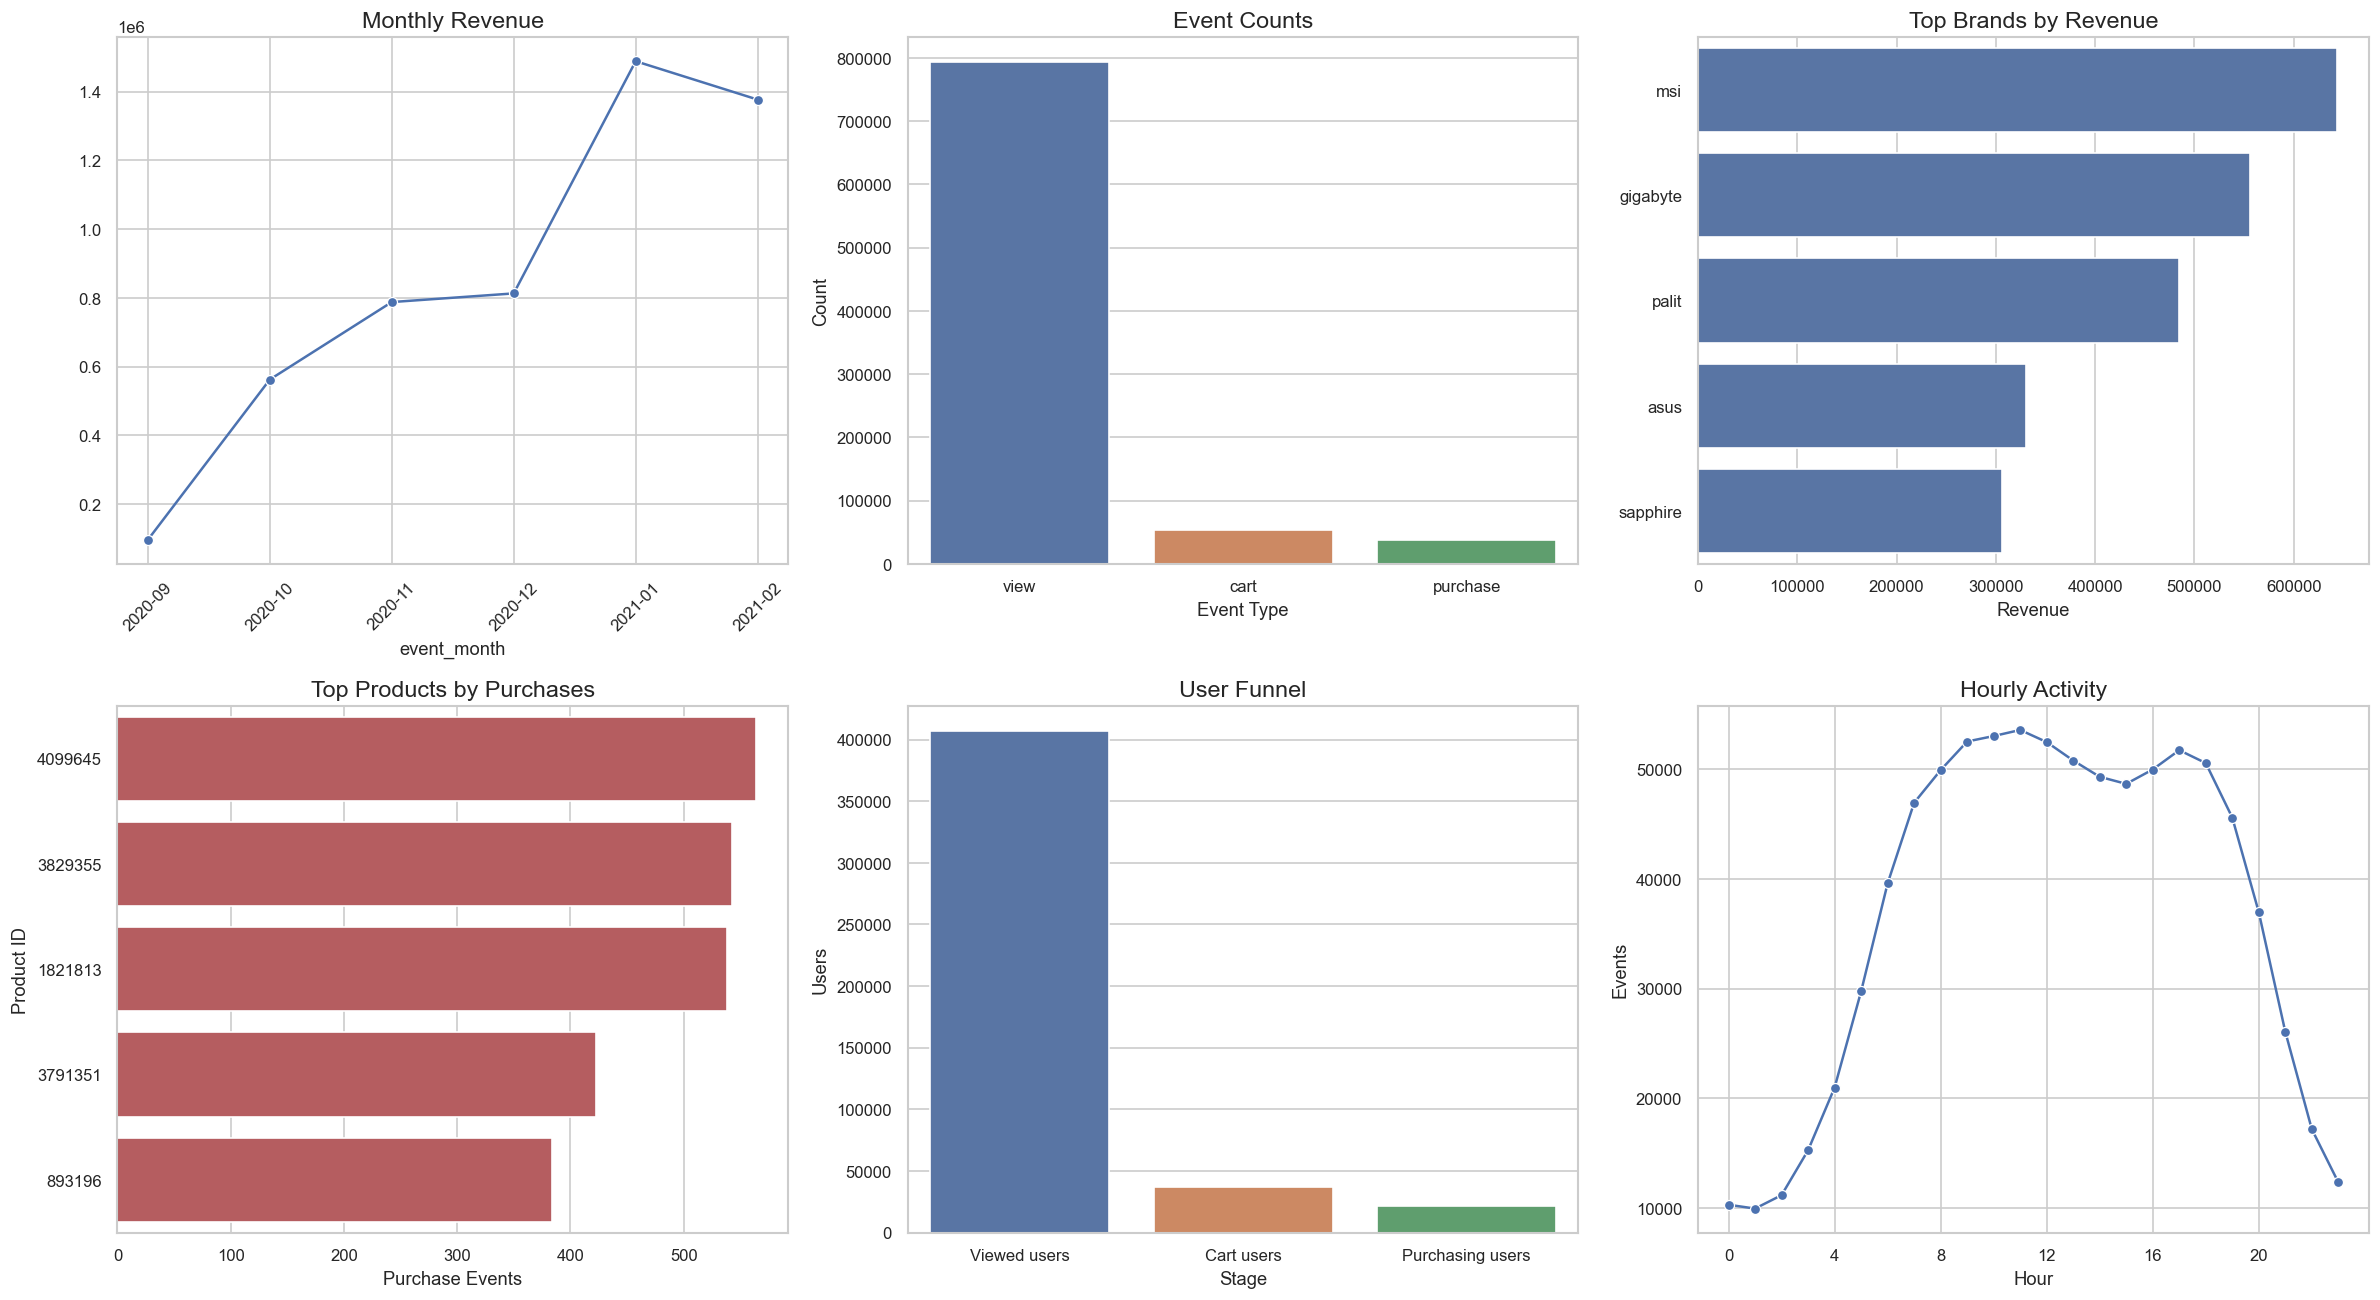

In [14]:
top_brand_dashboard = top_brand_chart.head(5)
top_product_dashboard = top_product_chart.head(5)

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

sns.lineplot(x=monthly_revenue.index, y=monthly_revenue.values, marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Monthly Revenue")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.barplot(x=event_counts.index, y=event_counts.values, hue=event_counts.index, legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Event Counts")
axes[0, 1].set_xlabel("Event Type")
axes[0, 1].set_ylabel("Count")

sns.barplot(data=top_brand_dashboard, x="revenue", y="brand", ax=axes[0, 2], color="#4c72b0")
axes[0, 2].set_title("Top Brands by Revenue")
axes[0, 2].set_xlabel("Revenue")
axes[0, 2].set_ylabel("")

sns.barplot(data=top_product_dashboard, x="purchases", y="product_id", ax=axes[1, 0], color="#c44e52")
axes[1, 0].set_title("Top Products by Purchases")
axes[1, 0].set_xlabel("Purchase Events")
axes[1, 0].set_ylabel("Product ID")

sns.barplot(data=funnel_summary, x="stage", y="users", hue="stage", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("User Funnel")
axes[1, 1].set_xlabel("Stage")
axes[1, 1].set_ylabel("Users")

sns.lineplot(x=hourly_activity.index, y=hourly_activity.values, marker="o", ax=axes[1, 2])
axes[1, 2].set_title("Hourly Activity")
axes[1, 2].set_xlabel("Hour")
axes[1, 2].set_ylabel("Events")
axes[1, 2].set_xticks(range(0, 24, 4))

plt.tight_layout()
plt.show()

## 10. Export Analyst Outputs

These exports make it easier to reuse the results in Excel, Power BI, Tableau, or a management presentation.

In [15]:
kpi_summary.to_csv(OUTPUT_DIR / "kpi_summary.csv", index=False)
funnel_summary.to_csv(OUTPUT_DIR / "funnel_summary.csv", index=False)
brand_revenue.reset_index().to_csv(OUTPUT_DIR / "brand_revenue.csv", index=False)
category_revenue.reset_index().to_csv(OUTPUT_DIR / "category_revenue.csv", index=False)
product_purchases.reset_index().to_csv(OUTPUT_DIR / "product_purchases.csv", index=False)
low_conversion_products.reset_index().to_csv(OUTPUT_DIR / "low_conversion_products.csv", index=False)
segment_table.to_csv(OUTPUT_DIR / "user_segments.csv", index=False)
clean.to_csv(OUTPUT_DIR / "events_cleaned.csv", index=False)

sorted(OUTPUT_DIR.glob("*.csv"))

[WindowsPath('D:/DataAnalyst/case_study/outputs/brand_revenue.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/category_revenue.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/events_cleaned.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/funnel_summary.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/kpi_summary.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/low_conversion_products.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/product_purchases.csv'),
 WindowsPath('D:/DataAnalyst/case_study/outputs/user_segments.csv')]

## 11. Final Business Recommendations

The job of the analyst is not to stop at the metric. The next step is to explain what the numbers mean and what the business should do with them.

In [16]:
top_month = monthly_revenue.idxmax()
top_month_revenue = monthly_revenue.max()
videocard_share = category_revenue.loc["computers.components.videocards", "revenue"] / total_revenue
unknown_brand_share = brand_revenue.loc["Unknown", "revenue"] / total_revenue

findings = pd.DataFrame(
    [
        {
            "Finding": "The biggest funnel problem is getting users from view to cart.",
            "Evidence": f"Only {fmt_percent(view_to_cart_user_rate)} of viewers added a product to cart, while cart-to-purchase conversion was {fmt_percent(cart_to_purchase_user_rate)} at the user level.",
            "Recommendation": "Improve product page persuasion: clearer pricing, stronger value messaging, product reviews, and cart-focused calls to action.",
        },
        {
            "Finding": "Revenue peaked in January 2021 and remained strong in February 2021.",
            "Evidence": f"January 2021 generated {fmt_currency(top_month_revenue)} in revenue, the highest monthly total in the dataset.",
            "Recommendation": "Replicate the campaigns, assortment, and promotional timing that supported early-2021 performance.",
        },
        {
            "Finding": "A single category drives a large share of revenue.",
            "Evidence": f"`computers.components.videocards` contributed {fmt_percent(videocard_share)} of total revenue.",
            "Recommendation": "Protect inventory, pricing, and merchandising for high-value core categories while testing cross-sell opportunities into adjacent products.",
        },
        {
            "Finding": "Missing product attributes are materially affecting reporting quality.",
            "Evidence": f"Unknown brands account for {fmt_percent(unknown_brand_share)} of revenue, which weakens brand-level decision-making.",
            "Recommendation": "Improve catalog completeness for brand and category fields so management can trust brand and assortment reporting.",
        },
    ]
)
display(findings)

display(
    Markdown(
        f'''
### Management Summary

1. **Reduce view-to-cart friction.** The largest opportunity sits at the top of the funnel, where most users browse but do not add items to cart.
2. **Double down on proven revenue drivers.** January 2021 was the strongest month, and video cards were the dominant revenue category.
3. **Retarget cart abandoners.** There are **{int(((user_summary["cart"] > 0) & (user_summary["purchase"] == 0)).sum()):,}** users who showed purchase intent but did not convert.
4. **Fix data quality gaps.** Unknown brand/category values should be reduced to strengthen merchandising and marketing decisions.
'''
    )
)

,Finding,Evidence,Recommendation
0,The biggest funnel problem is getting users fr...,"Only 9.08% of viewers added a product to cart,...",Improve product page persuasion: clearer prici...
1,Revenue peaked in January 2021 and remained st...,"January 2021 generated $1,488,410.57 in revenu...","Replicate the campaigns, assortment, and promo..."
2,A single category drives a large share of reve...,`computers.components.videocards` contributed ...,"Protect inventory, pricing, and merchandising ..."
3,Missing product attributes are materially affe...,"Unknown brands account for 11.60% of revenue, ...",Improve catalog completeness for brand and cat...



### Management Summary

1. **Reduce view-to-cart friction.** The largest opportunity sits at the top of the funnel, where most users browse but do not add items to cart.
2. **Double down on proven revenue drivers.** January 2021 was the strongest month, and video cards were the dominant revenue category.
3. **Retarget cart abandoners.** There are **16,896** users who showed purchase intent but did not convert.
4. **Fix data quality gaps.** Unknown brand/category values should be reduced to strengthen merchandising and marketing decisions.
